In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

First we'll define a quantum circuit that implements a query gate for one of the four functions $f1$, $f2$, $f3$, or $f4$, from one bit to one bit described previously. 

As we already mentioned, the implementation of query gates is not really a part of Deutsch's algorithm itself; here we're essentially just showing one way to prepare the input, in the form of a circuit implementation of a query gate.

___
### The Four Boolean Functions

Deutsch's algorithm considers the four possible functions

$$
f:\{0,1\}\rightarrow\{0,1\}.
$$

Using Qiskit's convention, the oracle acts as

$$
|y\rangle|x\rangle
\rightarrow
|y\oplus f(x)\rangle|x\rangle,
$$

where `q[0]` is the input qubit \(x\) and `q[1]` is the target qubit \(y\).

There are only four possible functions:

| Case  | Function           | Description                   |
| ----- | ------------------ | ----------------------------- |
| **1** | \(f(x)=0\)         | Always outputs 0              |
| **2** | \(f(x)=x\)         | Outputs the input unchanged   |
| **3** | \(f(x)=1\oplus x\) | Flips the input: 0 → 1, 1 → 0 |
| **4** | \(f(x)=1\)         | Always outputs 1              |

The corresponding oracle gates are:

* **Case 1:** No gates
* **Case 2:** CNOT, because `q[1]` must depend on `q[0]`
* **Case 3:** CNOT + X, adding a constant flip
* **Case 4:** X, because `q[1]` must always be flipped


In [3]:
def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

We can see what each circuit looks like using the draw method. Here's the circuit for the function $f3$:

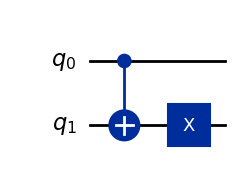

In [4]:
display(deutsch_function(3).draw(output="mpl"))